100%|██████████| 50/50 [00:19<00:00,  2.51it/s]


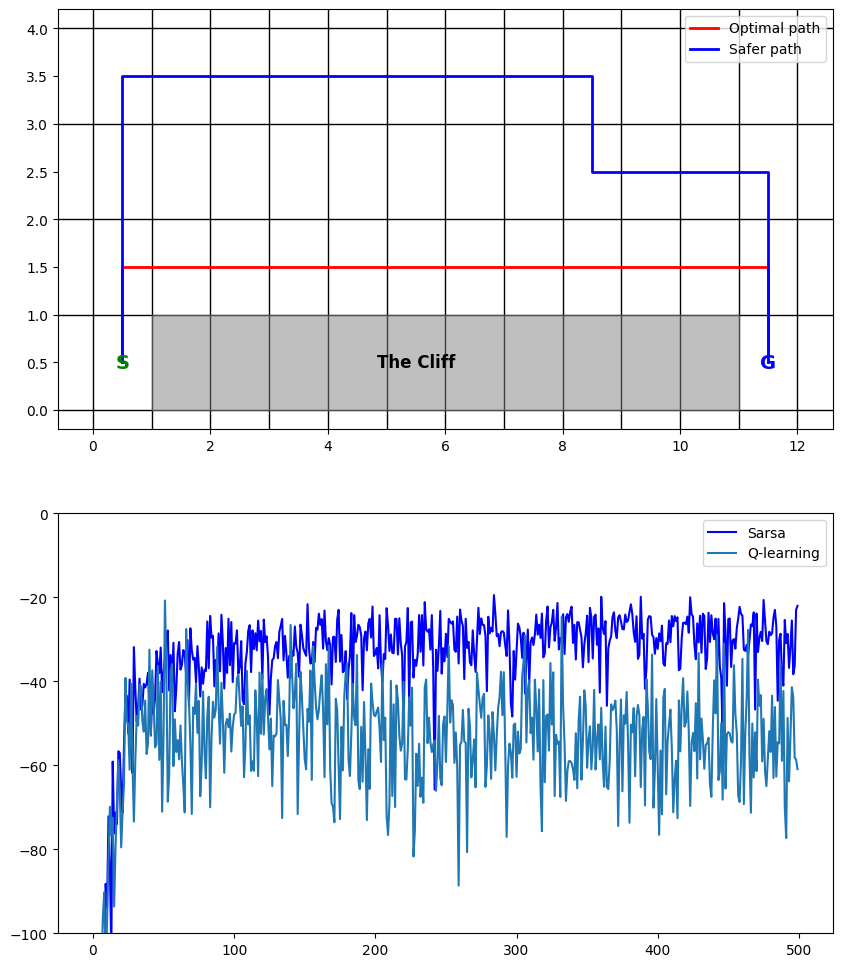

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import seaborn as sns
import gymnasium as gym
env = gym.make("CliffWalking-v0")
num_episodes=500
num_runs=50

#possible actions for a particular state
def possible_actions(observation):
    l=[]
    for i in range(4):
        if i==0 and observation not in range(0,12):
            l.append(i)
        elif i==1 and observation not in range(11,48,12):
            l.append(i)
        elif i==2 and observation not in range(36,48):
            l.append(i)
        elif i==3 and observation not in range(0,37,12):
            l.append(i)
    return l


#intialize q_values
def init_q_values():
    q_values={}
    for i in range(37):
        q_values[i]={}
        actions=possible_actions(i)
        for j in actions:
            q_values[i][j]=0
    q_values[47]={}
    for i in range(4):
        q_values[47][i]=0
    return q_values

#epislon greedy policy
def take_action(q_values,epsilon,observation):
    if np.random.rand()<epsilon:
        action=np.random.choice(list(q_values[observation].keys()))
    else:
        action=np.nanargmax([q_values[observation][i] if i in q_values[observation] else np.nan for i in range(4)])
    return action


def sarsa(epsilon,alpha,gamma=1):
    sums=np.zeros(num_episodes)
    for j in tqdm(range(num_runs)):
        q_values=init_q_values()
        for i in range(num_episodes):
            observation, info = env.reset()
            curr_sum=0
            action=take_action(q_values,epsilon,observation)
            while True:
                new_observation, reward, terminated, truncated, info = env.step(action)
                new_action=take_action(q_values,epsilon,new_observation)
                q_values[observation][action]=q_values[observation][action]+alpha*(reward+gamma*q_values[new_observation][new_action]-q_values[observation][action])
                observation=new_observation
                action=new_action
                curr_sum+=reward
                if terminated or truncated:
                    break
            sums[i]+=curr_sum
    sums/=num_runs
    return sums,q_values

def qlearning(epsilon,alpha,gamma=1):
    sums=np.zeros(num_episodes)
    for j in tqdm(range(num_runs)):
        q_values=init_q_values()
        for i in range(num_episodes):
            observation, info = env.reset()
            curr_sum=0
            while True:
                if np.random.rand()<epsilon:
                    action=np.random.choice(list(q_values[observation].keys()))
                else:
                    action=np.nanargmax([q_values[observation][i] if i in q_values[observation] else np.nan for i in range(4)])

                new_observation, reward, terminated, truncated, info = env.step(action)
                q_values[observation][action]=q_values[observation][action]+alpha*(reward+gamma*np.max(list(q_values[new_observation].values()))-q_values[observation][action])
                observation=new_observation
                curr_sum+=reward
                # env.render()
                if terminated or truncated:
                    break
            sums[i]+=curr_sum
    sums/=num_runs
    return sums,q_values


#drawing the policy
def draw_optimal_policy(q_values):
    state,_=env.reset()
    states=[]
    states.append(state)
    while True:
        action=np.nanargmax([q_values[state][i] if i in q_values[state] else np.nan for i in range(4)])
        new_observation, reward, terminated, truncated, info=env.step(action)
        state=new_observation
        states.append(state)
        if terminated:
            break
    return states


sums_1,q_values_1=qlearning(0.1,0.5)
sums_2,q_values_2=sarsa(0.1,0.5)



#draw the grid
grid_width, grid_height = 12, 4
fig, axes = plt.subplots(2,1,figsize=(10, 12))
ax=axes[0]
for x in range(grid_width + 1):
    ax.axvline(x, lw=1, color='black', zorder=0)
for y in range(grid_height + 1):
    ax.axhline(y, lw=1, color='black', zorder=0)
ax.text(0.5, 0.5, 'S', ha='center', va='center', fontsize=14, color='green', fontweight='bold')
ax.text(11.5, 0.5, 'G', ha='center', va='center', fontsize=14, color='blue', fontweight='bold')
cliff_x = np.arange(1, 11)  # Cliff spans from (1,0) to (10,0)
cliff_y = np.zeros(len(cliff_x))
ax.fill_betweenx([0, 1], 1, 11, color='gray', alpha=0.5)
ax.text(5.5, 0.5, 'The Cliff', ha='center', va='center', fontsize=12, color='black', fontweight='bold')


#plot the optimal path
optimal_path = draw_optimal_policy(q_values_1)
optimal_path_x=[i%12+0.5 for i in optimal_path]
optimal_path_y=[3-i//12+0.5 for i in optimal_path]
ax.plot(optimal_path_x, optimal_path_y, color='red', lw=2, label='Optimal path')


#plot the safer path
safer_path=draw_optimal_policy(q_values_2)
safer_path_x=[i%12+0.5 for i in safer_path]
safer_path_y=[3-i//12+0.5 for i in safer_path]
ax.plot(safer_path_x, safer_path_y, color='blue', lw=2, label='Safer path')
ax.legend()


ax1=axes[1]
plt.plot(range(0,500),sums_2,label='Sarsa',color='blue')
ax1.plot(range(0,500),sums_1,label='Q-learning')
ax1.set_ylim(-100,0)
ax1.legend()
plt.show()
